# A/B Test of Checkout Conversion

**Author: Tajamul Khan**

Does a checkout change improve user conversion?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A product team must decide whether evidence supports shipping a checkout treatment.

Estimate conversion lift, uncertainty and allocation balance at user level.

## Data contract and KPI definitions

One row per randomly assigned user, one binary conversion during a fixed window. Absolute lift is treatment minus control; percentage points differ from relative percent lift. Decision rule: lower 95% bound >0 and SRM p≥0.01; commercial guardrails are still required.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (12000, 3)


,user_id,variant,converted
0,1,Treatment,0
1,2,Control,0
2,3,Treatment,0
3,4,Treatment,0
4,5,Treatment,0


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
user_id,int64,0,12000
variant,object,0,2
converted,int64,0,2


## Action: analysis

Check sample ratio mismatch, calculate an unpooled 95% lift interval and a pooled two-proportion test with a predeclared decision rule.

In [3]:
from scipy.stats import norm, chisquare
assert df.user_id.is_unique and df.converted.isin([0,1]).all()
summary=df.groupby('variant').agg(users=('user_id','size'),conversions=('converted','sum'));summary['rate']=summary.conversions/summary.users
c,t=summary.loc['Control'],summary.loc['Treatment']; lift=t.rate-c.rate
se=np.sqrt(c.rate*(1-c.rate)/c.users+t.rate*(1-t.rate)/t.users)
lo,hi=lift-1.96*se,lift+1.96*se
pooled=summary.conversions.sum()/summary.users.sum();z=lift/np.sqrt(pooled*(1-pooled)*(1/c.users+1/t.users));p=2*norm.sf(abs(z));srm=chisquare(summary.users).pvalue
metrics={'Absolute lift (pp)':100*lift,'95% CI lower (pp)':100*lo,'95% CI upper (pp)':100*hi,'Two-sided p-value':p,'Allocation SRM p-value':srm}
print('Decision:', 'Evidence of positive lift; review guardrails before rollout' if lo>0 and srm>=.01 else 'Do not claim a validated improvement')
chart=summary.rate*100; ylabel='User conversion (%)'

Decision: Evidence of positive lift; review guardrails before rollout


## Deep dive: Uncertainty and practical significance

The interval concerns absolute conversion lift. A statistically positive change can still be too small to justify implementation cost; a practical threshold must be set before a real experiment.

Estimated absolute lift is 1.897 percentage points (95% CI 0.725 to 3.068). Review commercial guardrails before rollout.
Out[4]: 121


,estimate_pp,lower_95_pp,upper_95_pp
Treatment minus control,1.8967,0.7254,3.0679


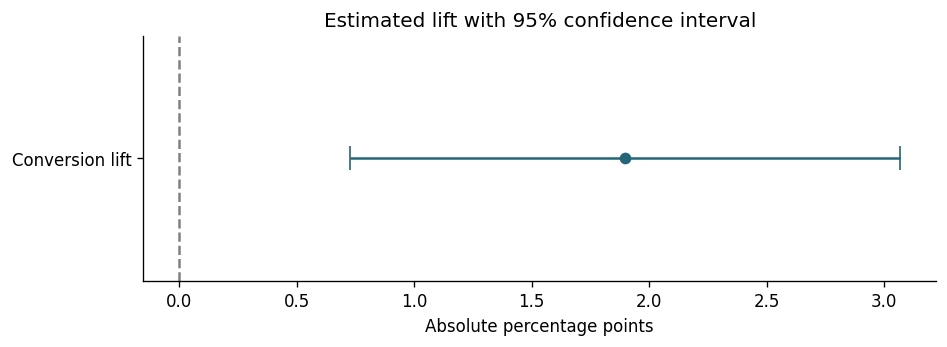

In [4]:

detail=pd.DataFrame({'estimate_pp':[100*lift],'lower_95_pp':[100*lo],'upper_95_pp':[100*hi]},index=['Treatment minus control'])
display(detail.round(4))
fig,ax=plt.subplots(figsize=(8,3));ax.errorbar(100*lift,0,xerr=100*1.96*se,fmt='o',color='#246577',capsize=7);ax.axvline(0,color='gray',ls='--');ax.set_yticks([0],['Conversion lift']);ax.set_xlabel('Absolute percentage points');ax.set_title('Estimated lift with 95% confidence interval');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
recommendation=f'Estimated absolute lift is {100*lift:.3f} percentage points (95% CI {100*lo:.3f} to {100*hi:.3f}). '+('Review commercial guardrails before rollout.' if lo>0 and srm>=.01 else 'Do not claim a validated improvement; review uncertainty and experiment validity.')

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,users,conversions,rate
variant,,,
Control,5991,675,0.1127
Treatment,6009,791,0.1316


,value
Absolute lift (pp),1.896688
95% CI lower (pp),0.725430
95% CI upper (pp),3.067946
Two-sided p-value,0.001512
Allocation SRM p-value,0.869482


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['users', 'conversions']


,variant,users,conversions,conversion_pct
0,Control,5991,675,11.266900
1,Treatment,6009,791,13.163588


## Visual interpretation

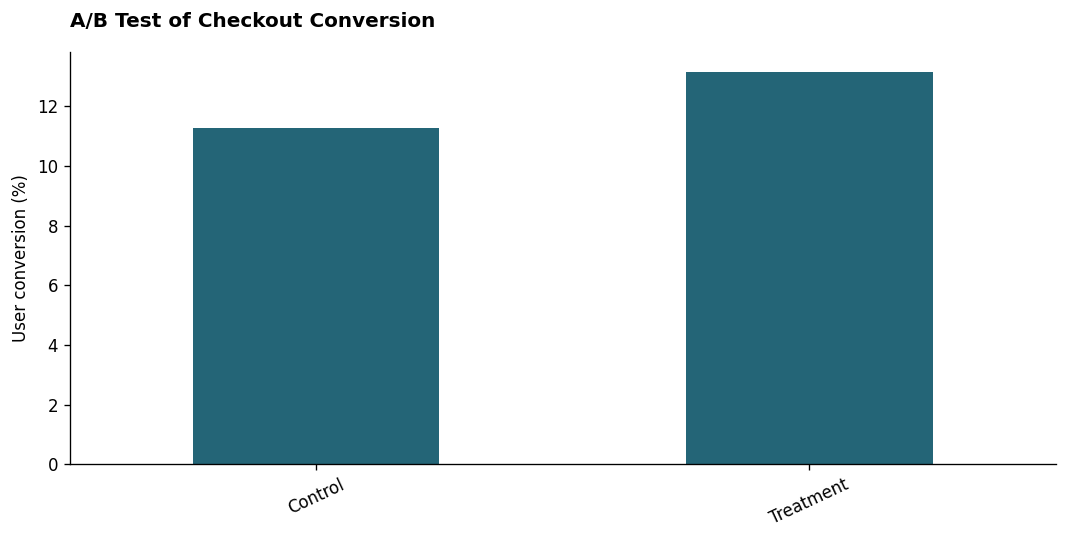

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('A/B Test of Checkout Conversion',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>A/B Test of Checkout Conversion</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>A/B Test of Checkout Conversion</h1><p>Does a checkout change improve user conversion?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>One fixed-horizon outcome and independent users are assumed. The ordinary interval is approximate; no peeking or multiple-testing adjustment is included.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

One fixed-horizon outcome and independent users are assumed. The ordinary interval is approximate; no peeking or multiple-testing adjustment is included.

**Next step:** Pre-register power, guardrails and a minimum practically important effect before collecting real data.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.